(02-05-crsp-tape)=

# De CRSP-tape: data als machine

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1959–1968, met een naspel tot 1999.

**Wat we al weten.** [Markowitz, Roy en Tobin](#01-04-markowitz) gaven een theorie
van keuze die draait op verwachte rendementen en covarianties. Die theorie strandt op
de invoer: verwachte rendementen zijn slecht meetbaar. In
[de lecture over rendementen](#00-01-rendementen) bouwden we het eerste gemeten
marktrendement na, de 9,0% per jaar van Fisher en Lorie. Het rekenkundige gemiddelde over
dezelfde 35 jaar, 11,7%, had een standaardfout van 3,9 procentpunt. Daar namen we aan dat "het rendement van de markt" één
welbepaald getal is.

**Welke vraag staat open.** Wat doet de bouw van een rendementsdatabase, en vooral
de omgang met verdwenen bedrijven, met het gemiddelde rendement dat eruit komt?
```

## Overzicht

Hoe meten we het gemiddelde rendement van alle aandelen, als een deel van die
aandelen onderweg verdwijnt? Alleen door de verdwenen bedrijven mee te tellen, tot en
met hun laatste verlies: wie ze weglaat, meet een te hoog gemiddelde, vooral bij
kleine aandelen. Meer data halen de fout niet onder de ruis:
de fout door ontbrekende delisting returns blijft staan, en die van overlevenden
krimpt hoogstens even snel als de ruis. In deze lecture:

- rekenen we met de hand na wat één faillissement met een marktgemiddelde doet;
- leiden we af hoe groot de fout is als de database het laatste rendement van
  geschrapte aandelen mist, en als ze alleen overlevenden bevat;
- simuleren we een universum zonder size-premie en meten er toch een;
- repliceren we wat de weging met een eeuw marktrendement doet, en toetsen we de
  gepubliceerde correcties van Shumway aan de formule.

Eind jaren vijftig wist niemand hoeveel een belegger op lange termijn verdiende met
een willekeurig NYSE-aandeel, omdat de data niet bestonden. Vanaf 1960 bouwde het
Center for Research in Security Prices in Chicago, met geld van Merrill Lynch, die data
op. James Lorie en Lawrence Fisher lieten
maandprijzen, dividenden en kapitaalmutaties van alle gewone NYSE-aandelen vanaf
januari 1926 verzamelen en op magneetband zetten. De resultaten verschenen in 1964
{cite}`FisherLorie1964`, het jaaroverzicht tot 1965 in 1968 {cite}`FisherLorie1968`.

Met dat werk begint het tijdvak: de event study en de toetsen van het CAPM draaiden
erop. Voor theorie of feit is de tape geen van beide:
ze toetst geen theorie en verklaart geen feit, ze meet. Maar elke meetbeslissing heeft
een voorspelbaar teken, en die fout kan groter zijn dan
[de standaardfout van 2%](#00-01-rendementen): de onzekerheid die een eeuw
jaarrendementen met 20% volatiliteit in een gemiddelde laat.

## Intuïtie: waarom zou dit waar zijn?

De vraag lijkt eenvoudig: neem alle aandelen van 1926, volg ze tot nu, en tel.
Maar wie het probeert, krijgt van de data drie vragen terug.

De eerste: wat is het rendement van een aandeel? Een koers die op de dag van een
dividend daalt, is geen verlies. Het geld is naar de aandeelhouder gegaan. Een koers
die bij een split halveert, is ook geen verlies, want de houder heeft nu twee stukken.

De tweede: welke aandelen tellen mee? Een bedrijf dat failliet gaat, verdwijnt van de
beurs. Wie vandaag de lijst van genoteerde bedrijven opvraagt en terugrekent tot 1926,
meet alleen de overlevenden. Dat zijn per definitie de bedrijven die nooit zo diep
daalden dat ze werden geschrapt.

De derde is subtieler. Ook als de verdwenen bedrijven in de database staan,
ontbreekt vaak de *delisting return* (het rendement tussen de laatste beurskoers en
wat de houder na schrapping nog krijgt). Bij een faillissement is dat rendement groot
en negatief. Juist dan ontbreekt het het vaakst.

Geen van die keuzes voegt ruis toe. Ze voegen een vertekening toe met een voorspelbaar
teken. We verwachten dus dat het gemeten gemiddelde *te hoog* uitvalt, het meest bij
kleine aandelen, omdat die het vaakst failliet gaan. En we verwachten dat meer data de
fout niet onder de ruis halen:
de fout door ontbrekende delisting returns blijft staan, en die van overlevenden
krimpt hoogstens even snel als de ruis.

## Toy-voorbeeld: vijf aandelen, vier perioden

De imports staan in de eerste cel.

In [1]:
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

**Opzet.** Vijf aandelen, prijzen op $t = 0, \dots, 4$, zonder dividenden of splits.
Aandeel C wordt in periode 3 geschrapt: de laatste beurskoers is 6, en daarna is het aandeel
onderhands nog 1,50 waard.

| aandeel | $t=0$ | $t=1$ | $t=2$ | $t=3$ | $t=4$ | gebeurtenis |
|---|---|---|---|---|---|---|
| A | 40 | 44 | 44 | 44 | 48,40 | — |
| B | 60 | 60 | 66 | 66 | 59,40 | — |
| C | 10 | 8 | 6 | (1,50) | — | geschrapt in periode 3 |
| D | 50 | 50 | 55 | 55 | 60,50 | — |
| E | 25 | 30 | 30 | 30 | 27 | — |

**Het recept.** Het rendement is de waarde aan het eind van de periode gedeeld door de
prijs aan het begin, min één. Voor een geschrapt aandeel is de waarde aan het eind de
waarde na schrapping.

**Stap 1.** C in periode 3: $1{,}50/6 - 1 = -75\%$. Dat is de delisting return.

De overige rendementen volgen direct uit de prijzen:

| periode | A | B | C | D | E |
|---|---|---|---|---|---|
| 1 | +10% | 0% | −20% | 0% | +20% |
| 2 | 0% | +10% | −25% | +10% | 0% |
| 3 | 0% | 0% | −75% | 0% | 0% |
| 4 | +10% | −10% | — | +10% | −10% |

**Stap 2.** Het equal-weighted marktrendement, op drie manieren. Correct telt alle
aandelen die aan het begin van de periode bestaan. Zonder delisting return ontbreekt C
in periode 3. Bij alleen overlevenden ontbreekt C in alle perioden, want de lijst van
$t=4$ kent C niet meer.

- Correct: $2{,}0\%$, $-1{,}0\%$, $-75/5 = -15{,}0\%$ en $0{,}0\%$; gemiddeld $-3{,}50\%$.
- Zonder delisting return: periode 3 wordt $0/4 = 0{,}0\%$; gemiddeld $+0{,}25\%$.
- Alleen overlevenden: $30/4 = 7{,}5\%$, $20/4 = 5{,}0\%$, $0\%$ en $0\%$; gemiddeld $+3{,}13\%$.

**Stap 3.** Cumulatief vermenigvuldigen we de bruto rendementen. Correct:
$1{,}02 \times 0{,}99 \times 0{,}85 = 0{,}8583$, dus $-14{,}17\%$. Zonder delisting
return: $1{,}02 \times 0{,}99 = 1{,}0098$, dus $+0{,}98\%$. Overlevenden:
$1{,}075 \times 1{,}05 = 1{,}12875$, dus $+12{,}88\%$.

De code bouwt dezelfde rendementen uit prijzen en de waarde na schrapping, zoals een
database dat doet.

In [2]:
prices = pd.DataFrame(
    {"A": [40, 44, 44, 44, 48.4], "B": [60, 60, 66, 66, 59.4],
     "C": [10, 8, 6, np.nan, np.nan], "D": [50, 50, 55, 55, 60.5],
     "E": [25, 30, 30, 30, 27]},
    dtype=float,
)
delisting_value = {"C": (3, 1.50)}    # value after delisting, realised in period 3


def total_returns(prices, delisting_value):
    """Holding-period returns, with the delisting return for delisted stocks."""
    returns = prices / prices.shift(1) - 1
    for stock, (period, value) in delisting_value.items():
        returns.loc[period, stock] = value / prices.loc[period - 1, stock] - 1
    return returns.loc[1:]


correct = total_returns(prices, delisting_value)
no_delisting = correct.copy()
no_delisting.loc[3, "C"] = np.nan         # the database misses C's last return
survivors = correct.drop(columns="C")     # C is not on the list at t = 4

markets = pd.DataFrame({"correct": correct.mean(axis=1),
                        "zonder delisting return": no_delisting.mean(axis=1),
                        "alleen overlevenden": survivors.mean(axis=1)})
pd.DataFrame({
    "gemiddeld, hand": [-0.035, 0.0025, 0.03125],
    "gemiddeld, code": markets.mean(),
    "cumulatief, hand": [-0.14167, 0.0098, 0.12875],
    "cumulatief, code": (1 + markets).prod() - 1,
}).round(5)

,"gemiddeld, hand","gemiddeld, code","cumulatief, hand","cumulatief, code"
correct,-0.03500,-0.03500,-0.14167,-0.14167
zonder delisting return,0.00250,0.00250,0.00980,0.00980
alleen overlevenden,0.03125,0.03125,0.12875,0.12875


Code en hand geven dezelfde getallen. Dezelfde vijf aandelen, en de markt verloor 14%
of won 13%, afhankelijk van één beslissing: wat er met het verdwenen aandeel gebeurt.
Beide fouten bestaan uit ontbrekende waarnemingen, zijn dus onzichtbaar, en maken de
markt allebei beter dan hij was.

## Theorie

We leiden vier dingen af. Eerst de definitie van een rendement in een database: het
recept uit het toy-voorbeeld, uitgebreid met dividend en split. Dan de kern: hoe groot de fout is als de database het
laatste rendement van geschrapte aandelen mist. Daarna survivorship, de extreme vorm
van dezelfde selectie. Tot slot wat de weging doet met een gemiddelde waarin kleine
aandelen meetellen.

### Opzet: het rendement in een database

*Waarom zou dit waar zijn?* Een rendement meet wat er gebeurt met het vermogen van een
houder die niets doet. Die houder ontvangt het dividend in contanten en krijgt bij een
split extra stukken. Wie een van die twee vergeet, ziet een verlies dat er niet is.

Naast de prijs $p_t$ en het dividend $d_{t+1}$ is er een *aanpassingsfactor*
$k_{t+1}$: het aantal aandelen op $t+1$ per aandeel op $t$. Een 2:1-split heeft
$k = 2$, een stockdividend van 5% heeft $k = 1{,}05$, en in een gewone maand is
$k = 1$.

:::{prf:definition} Totaalrendement
:label: def-crsp-tape-totaal

Het bruto totaalrendement van een aandeel tussen $t$ en $t+1$ is

```{math}
:label: eq-crsp-tape-totaal
R_{t+1} = \frac{k_{t+1}\, p_{t+1} + d_{t+1}}{p_t} .
```
:::

In woorden: wat de houder op $t+1$ heeft, gedeeld door wat hij op $t$ betaalde.

Een aandeel van 44 dat 2 dividend uitkeert en daarna 42 noteert, heeft $(42 + 2)/44 - 1 = 0\%$,
niet $-4{,}55\%$. Een aandeel van 60 dat 2:1 splitst en daarna 33 noteert, heeft
$2 \times 33/60 - 1 = +10\%$, niet $-45\%$. CRSP slaat precies deze
bouwstenen op: de ruwe prijs, de uitkeringen en een cumulatieve factor. Het herbeleggen
van dividenden is een keuze. Die keuze scheidt de 9,0% van Fisher en Lorie, met
herbelegde dividenden, van hun 6,9% zonder herbelegging in [](#00-01-rendementen).

### Het kernresultaat: de ontbrekende delisting return

Mist de database het laatste rendement van geschrapte aandelen, dan valt het gemiddelde
te hoog uit: met de schrappingskans maal het gemiste verlies. Eerst het rendement van
een geschrapt aandeel. Een aandeel wordt in de loop van periode $t+1$ geschrapt. De laatste beurskoers is
$p^{\text{laatst}}$. Daarna krijgt de houder nog een waarde $v$: een overnameprijs, een
liquidatie-uitkering of een onderhandse koers. Het rendement over de periode is dan

```{math}
:label: eq-crsp-tape-delisting
R_{t+1} = \frac{p^{\text{laatst}}}{p_t} \cdot \frac{v}{p^{\text{laatst}}}
       = \left(1 + r^{\text{deel}}_{t+1}\right)\left(1 + r^{\text{DL}}_{t+1}\right).
```

In woorden: het rendement tot de laatste handelsdag, $r^{\text{deel}}$, maal het
rendement daarna, de delisting return $r^{\text{DL}} = v/p^{\text{laatst}} - 1$. CRSP
bewaart $r^{\text{DL}}$ als apart veld. {cite:t}`Shumway1997` liet zien dat dat veld in zijn
steekproef, die in 1962 begint, leeg was voor de meeste schrappingen om slechte
prestaties. Hieronder is $r^{\text{s}}$ het netto rendement van een geschrapt aandeel over de hele
periode, dus [](#eq-crsp-tape-delisting) min één. In het toy-voorbeeld valt $r^{\text{s}}$ samen met
de delisting return, omdat de laatste koers daar ook de beginkoers van de periode is.

*Waarom zou dit waar zijn?* Een onderzoeker middelt de rendementen die in de database
staan. Juist de laagste rendementen van de maand, die van net failliete bedrijven,
staan er niet in. Het gemeten gemiddelde stijgt dus, met de kans op zo'n schrapping
maal de afstand tussen het ontbrekende rendement en de rest.

:::{prf:theorem} Bias door ontbrekende delisting returns
:label: thm-crsp-tape-delisting

Neem een equal-weighted portefeuille van $N$ aandelen in periode $t+1$. Elk aandeel wordt
onafhankelijk met kans $h$ geschrapt, met netto rendement $r^{\text{s}}$. Anders is het netto
rendement $r^{a}$, met verwachting $\mu_a$, onafhankelijk van de schrapping. De database mist de
rendementen van geschrapte aandelen en middelt over de rest. Dan geldt voor
$N \to \infty$

```{math}
:label: eq-crsp-tape-delistingbias
\plim \bar r^{\text{database}}_{t+1} - \plim \bar r^{\text{waar}}_{t+1}
  = h\,\left(\mu_a - r^{\text{s}}\right) .
```
:::

Hier is $\plim$ de kanslimiet: de waarde waar het gemiddelde naartoe gaat bij veel
aandelen. In woorden: de fout is de schrappingskans maal hoe ver het ontbrekende
rendement onder het gewone rendement ligt. Het bewijsidee: het ware gemiddelde gaat naar
$(1-h)\mu_a + h\,r^{\text{s}}$, het databasegemiddelde naar $\mu_a$.

:::{prf:proof}
:class: dropdown

Het ware gemiddelde is $N^{-1}\sum_i r_{i,t+1}$ en convergeert naar $(1-h)\mu_a + h\,r^{\text{s}}$.
Het databasegemiddelde loopt over de $(1-h)N$ niet-geschrapte aandelen. Omdat schrapping
en $r^{a}$ onafhankelijk zijn, hebben hun rendementen nog steeds verwachting $\mu_a$,
dus het gemiddelde convergeert naar $\mu_a$. Het verschil is
$\mu_a - (1-h)\mu_a - h\,r^{\text{s}} = h(\mu_a - r^{\text{s}})$. $\square$
:::

Het toy-voorbeeld is het kleinste geval. In periode 3 is $h = 1/5$, $\mu_a = 0$ en
$r^{\text{s}} = -75\%$, dus de fout is $0{,}2 \times 0{,}75 = 15$ procentpunt: precies het verschil
tussen $0{,}0\%$ en $-15{,}0\%$.

In echte data is $\mu_a$ ongeveer 1% per maand en ligt
$r^{\text{s}}$ tussen $-30\%$ en $-100\%$. De fout is dan vrijwel $h\,|r^{\text{s}}|$.

In de kleinste
Nasdaq-aandelen was $h$ ongeveer 3% per maand en $\mu_a$ 3,8% {cite}`ShumwayWarther1999`.
Met $r^{\text{s}} = -55\%$ is de fout dan $0{,}0295 \times 0{,}588 = 1{,}7$ procentpunt per maand. Zoals de intuïtie voorspelde, zit ze waar $h$ groot is,
bij kleine aandelen, en is daarom een fout in de size-premie, niet alleen in het niveau.
Voor een value-weighted portefeuille vervangt het marktwaardegewogen gemiddelde van
de $h_i$ de kans $h$. Dat gemiddelde is klein, omdat grote bedrijven zelden failliet
gaan.

### Wat het voorspelt: overlevenden en look-ahead

Survivorship bias is de extreme vorm van dezelfde selectie. Nu ontbreekt niet alleen
het laatste rendement, maar de hele geschiedenis van elk bedrijf dat vóór het einde
van de steekproef verdween.

*Waarom zou dit waar zijn?* Een bedrijf wordt geschrapt als zijn waarde onder een
drempel zakt. Wie overleeft, is die drempel nooit tegengekomen, en dat zegt iets over
zijn rendementen: ze waren hoger dan gemiddeld. Hoe dichter bij de drempel en hoe
volatieler het aandeel, hoe strenger de selectie. Een steekproef van overlevenden maakt
kleine aandelen dus mooier dan grote.

Het eenvoudigste model waarin dat exact kan: $Z_t = z_0 + \sigma W_t$ is de
log-afstand tot de schrappingsdrempel, met $W$ een standaard Brownse beweging en
$z_0 > 0$. Het bedrijf wordt geschrapt zodra $Z_t = 0$, bijvoorbeeld als de koers onder
de noteringseis van de beurs zakt. Er is geen drift, dus het ware verwachte logrendement
is nul. Het reflectieprincipe zegt dat een pad dat de drempel raakt, daarna even vaak
boven als onder de drempel eindigt. Daaruit volgt de kans om tot $T$ te overleven

```{math}
:label: eq-crsp-tape-overleefkans
P(\theta > T) = 2\,\Phi\!\left(\frac{z_0}{\sigma\sqrt{T}}\right) - 1 ,
```

met $\theta$ het moment van schrappen en $\Phi$ de standaardnormale verdelingsfunctie.
In woorden: de kans daalt naarmate de drempel dichterbij ligt ($z_0$ klein) of het
aandeel volatieler is.

:::{prf:theorem} Survivorship bias bij een absorberende drempel
:label: thm-crsp-tape-survivorship

In het model hierboven is het gemiddelde logrendement per jaar van de overlevenden

```{math}
:label: eq-crsp-tape-survivorship
\frac{\E\left[Z_T - z_0 \mid \theta > T\right]}{T}
  = \frac{z_0}{T}\left(\frac{1}{P(\theta > T)} - 1\right) > 0 .
```
:::

In woorden: de fout is de beginafstand per jaar, $z_0/T$, maal de kans op schrappen
gedeeld door de kans op overleven. Ze stijgt als de overleefkans daalt. Het bewijsidee: een proces
zonder drift houdt gemiddeld zijn beginwaarde, en de geschrapte paden staan op nul.
Alle beginwaarde zit dus in de overlevenden.

:::{prf:proof}
:class: dropdown

Zonder drift is $Z_t$ een martingaal, en $T \wedge \theta$ is een begrensde stoptijd. Volgens de
optional-stopping-stelling is $\E[Z_{T\wedge\theta}] = z_0$. Op $\{\theta \le T\}$ is
$Z_{T\wedge\theta} = 0$, dus

$$
z_0 = \E\left[Z_T \mathbf{1}\{\theta > T\}\right]
    = \E\left[Z_T \mid \theta > T\right] P(\theta > T) .
$$

Delen door $P(\theta > T)$, $z_0$ aftrekken en door $T$ delen geeft het resultaat. $\square$
:::

Neem een klein bedrijf met $z_0 = 1$ (een koers van 2,7 keer de drempel) en
$\sigma = 50\%$ per jaar. Het overleeft twintig jaar met kans
$2\Phi(0{,}447) - 1 = 0{,}345$. De overlevenden hebben een gemiddeld logrendement van
$(1/20)(1/0{,}345 - 1) = 9{,}5\%$ per jaar, terwijl het ware rendement nul is. Een groot
bedrijf met $z_0 = 3$ en $\sigma = 20\%$ overleeft vrijwel zeker, en zijn fout is een
honderdste procentpunt. Een steekproef van overlevenden maakt dus uit het niets een
size-premie van negen procentpunt. De cel rekent beide gevallen na.

In [3]:
def survivor_bias(x0, sigma, horizon):
    """Survival probability and survivors' mean log return per year (driftless, barrier at 0)."""
    p_survive = 2 * stats.norm.cdf(x0 / (sigma * np.sqrt(horizon))) - 1
    return p_survive, x0 / horizon * (1 / p_survive - 1)


pd.DataFrame(
    [survivor_bias(1.0, 0.50, 20), survivor_bias(3.0, 0.20, 20), survivor_bias(1.0, 0.50, 100)],
    index=["klein: z0 = 1, sigma = 50%", "groot: z0 = 3, sigma = 20%", "klein, na een eeuw"],
    columns=["overleefkans", "fout in gemiddeld logrendement per jaar"],
).round(5)

,overleefkans,fout in gemiddeld logrendement per jaar
"klein: z0 = 1, sigma = 50%",0.34528,0.09481
"groot: z0 = 3, sigma = 20%",0.99920,0.00012
"klein, na een eeuw",0.15852,0.05308


De tabel bevestigt de handberekening: 9,5% voor het kleine bedrijf, 0,012% voor het
grote. De derde rij gebruiken we hieronder. Zoals de intuïtie voorspelde, is de fout positief en het grootst bij kleine,
volatiele aandelen.

Meer jaren helpen, maar niet ten opzichte van de ruis. Voor grote $T$ gaat de fout in
[](#eq-crsp-tape-survivorship) naar $\sqrt{\pi/2}\,\sigma/\sqrt{T}$, ongeveer 1,25 keer de
standaardfout van het gemiddelde van één aandeel. Na een eeuw geeft de exacte formule
voor het kleine bedrijf nog $P = 2\Phi(0{,}2) - 1 = 0{,}159$ en een fout van
$0{,}01 \times (1/0{,}159 - 1) = 5{,}3\%$ per jaar; de cel hierboven rekent het na. Meer aandelen helpen niet:
middelen over $N$ overlevenden deelt de standaardfout door $\sqrt{N}$, maar laat de fout
staan.

Hetzelfde mechanisme werkt buiten aandelen. {cite:t}`BrownGoetzmannIbbotsonRoss1992`
lieten zien dat fondsen die na slechte jaren verdwijnen, de prestaties van de overlevenden
persistent laten lijken. Die selectie kon het toenmalige bewijs voor voorspelbare
fondsprestaties verklaren. In boekhouddata heet het backfill: als Compustat een bedrijf
toevoegt, voegt het vaak ook eerdere jaren toe, maar alleen voor bedrijven die dan nog
bestaan. {cite:t}`KothariShankenSloan1995` vermoedden dat een deel van de waardepremie
daardoor komt.

Eén fout werkt de andere kant op: *look-ahead bias* (vertekening doordat een strategie
informatie gebruikt die op het beslismoment nog niet bestond). Wie aandelen sorteert op
hun marktwaarde aan het *einde* van de maand, stopt de crashes van die maand in de
kleinste portefeuille. Kleine aandelen lijken dan slechter dan ze zijn. Een uitvoerbare
strategie sorteert alleen op wat op het beslismoment openbaar was. Daarom koppelen Fama
en French een jaarrekening pas een half jaar na het einde van het boekjaar aan
rendementen {cite}`FamaFrench1992`.

### Weging: equal-weighted tegenover value-weighted

*Waarom zou dit waar zijn?* Een value-weighted portefeuille houdt elk aandeel naar zijn
marktwaarde en hoeft niets te doen: een stijgend aandeel krijgt vanzelf meer gewicht.
Een equal-weighted portefeuille verkoopt elke maand winnaars en koopt verliezers bij,
tot alle gewichten weer $1/N$ zijn. Kleine aandelen wegen daarin even zwaar als grote.
Daarom duwen de fouten van kleine aandelen het equal-weighted gemiddelde vol omhoog, en
het value-weighted nauwelijks.

Met gewichten $w_{i,t}$ van de value-weighted portefeuille en $\sum_i (w_{i,t} - 1/N) = 0$
is het verschil tussen de twee rendementen

```{math}
:label: eq-crsp-tape-ewvw
R^{\text{EW}}_{t+1} - R^{\text{VW}}_{t+1}
  = \sum_i \left(\tfrac{1}{N} - w_{i,t}\right) R_{i,t+1}
  = -N \cdot \Cov_{\text{cs}}\!\left(w_{i,t},\, R_{i,t+1}\right) ,
```

met $\Cov_{\text{cs}}$ de covariantie over de aandelen in één periode. In woorden: het
rekenkundige verschil is positief als kleine aandelen in die periode beter deden. Het
verschil tussen de wegingen is dus zelf een size-premie.

Twee effecten komen daar nog bij. Het eerste is de winst uit herbalanceren
{cite}`BoothFama1992`. Een portefeuille die naar vaste gewichten wordt teruggezet,
groeit meetkundig sneller dan het gewogen gemiddelde van haar onderdelen. Met
$g \approx \mu - \tfrac12\sigma^2$, de meetkundige groei een halve variantie onder de
rekenkundige, geldt bij benadering:

```{math}
:label: eq-crsp-tape-bonus
g_p - \sum_i w_i g_i = \tfrac12\left(\sum_i w_i \sigma_i^2 - \sigma_p^2\right) \;\ge\; 0 .
```

In woorden: de winst is de helft van het variantieverlies door spreiding. Hier is $g$ de
meetkundige groeivoet, $\sigma_i$ de volatiliteit van aandeel $i$ en $\sigma_p$ die van
de portefeuille. Bij veel aandelen met $\sigma = 50\%$ en onderlinge correlatie 0,2 is
dat $\tfrac12 \times 0{,}25 \times 0{,}8 = 10\%$ per jaar. Het verwachte rendement stijgt
daardoor niet. Wel toont een equal-weighted index over een eeuw veel meer eindvermogen.

Het tweede effect is de bid-ask bias. Een slotkoers ligt op de bied- of de laatkoers,
niet op de ware prijs. Met een relatieve afwijking $\delta_t$ met gemiddelde nul en
variantie $s^2$ is het gemeten bruto rendement gemiddeld ongeveer $\E[R](1 + s^2)$, omdat
$\E[1/(1+\delta)] \approx 1 + s^2$. Bij een
spread van 10% van de koers is $\delta = \pm 5\%$ en $s^2 = 0{,}25\%$ per maand: drie
procentpunt per jaar. Een equal-weighted portefeuille erft die fout elke maand, een
buy-and-hold-portefeuille alleen aan begin en eind. {cite:t}`BlumeStambaugh1983`
vonden zo een jaarlijks size-effect dat half zo groot was als eerder gerapporteerd.

```{admonition} Samengevat
:class: tip

- Een rendement in een database telt dividend en split mee, [](#eq-crsp-tape-totaal).
- Een ontbrekende delisting return maakt het gemiddelde $h(\mu_a - r^{\text{s}})$ te hoog,
  [](#eq-crsp-tape-delistingbias): hoger bij een grotere schrappingskans $h$ of een
  groter verlies $|r^{\text{s}}|$.
- Een steekproef van overlevenden geeft een positief rendement waar het ware nul is,
  [](#eq-crsp-tape-survivorship): meer bij een lagere overleefkans.
- Equal-weighted gemiddelden erven deze fouten vol, plus herbalanceringswinst en bid-ask
  bias; value-weighted nauwelijks, [](#eq-crsp-tape-ewvw).
- De simulatie hierna vraagt: hoe groot zijn die fouten samen in steekproeven van
  dertig jaar, vergeleken met de steekproefruis?
```

## Simulatie: een universum met faillissementen

In een universum zonder size-premie meet een database zonder delisting returns een
premie van vijf procentpunt per jaar, en een database van overlevenden een van vijftien.
De steekproefruis is ongeveer één procentpunt. De simulatie zet de fouten uit de theorie
in één universum en vergelijkt ze met die ruis.

**Het model.** Er zijn 1000 aandelen, 30 jaar maanddata en 100 onafhankelijke
steekproeven. Elk aandeel heeft een log-marktwaarde $s_{i,t}$. De kans op schrapping in
maand $t+1$ hangt af van hoe klein het aandeel is ten opzichte van het gemiddelde,

$$
h_{i,t} = \frac{0{,}02}{1 + \exp\!\left(\left(s_{i,t} - \bar s_t + 2\right)/0{,}5\right)} ,
$$

zodat de kleinste aandelen tot 2% per maand kans op schrapping hebben. Een geschrapt
aandeel heeft over de maand rendement $r^{\text{s}} = -30\%$. Dat is de gemiddelde delisting return
die {cite:t}`Shumway1997` voor NYSE en AMEX reconstrueerde. Een nieuwe, kleine notering
neemt zijn plaats in. De overige aandelen krijgen een marktschok ($\sigma_m = 4{,}5\%$
per maand) en een eigen schok ($\sigma_\varepsilon = 12\%$ per maand).

**De cruciale keuze.** Het ware verwachte rendement is voor elk aandeel 1% per maand,
inclusief de kans op schrapping: $(1-h)(1+\mu_a) + h(1+r^{\text{s}}) = 1{,}01$. Een klein aandeel
krijgt dus een hogere drift $\mu_a$, die precies het verwachte verlies bij schrapping
goedmaakt. **Er is per constructie geen size-premie.** Alles wat we toch meten, komt uit
de database.

We meten tien size-decielen op vier manieren. De eerste is correct, de tweede mist de
delisting returns, de derde bevat alleen de aandelen die na dertig jaar nog genoteerd
zijn. De vierde sorteert met look-ahead, op de marktwaarde aan het einde van de maand.

De eerste cel bevat drie hulpfuncties. De functie `size_deciles` rangschikt de aandelen in een
steekproef per maand naar grootte en deelt de rang door een tiende van het aantal.
De functie `decile_mean` middelt een grootheid per deciel, met een lus over de tien decielen.
De functie `hazard` is de schrappingskans van hierboven.

In [4]:
def size_deciles(size, in_sample):
    """Size decile (0 = smallest) of every stock among the stocks in `in_sample`, per row."""
    size_in_sample = np.where(in_sample, size, np.inf)   # stocks outside the sample rank last, never in a decile
    rank = stats.rankdata(size_in_sample, axis=1, method="ordinal").astype(int) - 1   # 0 = smallest
    n_in_sample = in_sample.sum(axis=1, keepdims=True)
    return np.minimum(rank * 10 // np.maximum(n_in_sample, 1), 9)


def decile_mean(values, decile, in_sample):
    """Equal-weighted mean of `values` per size decile among `in_sample`, per row."""
    means = np.zeros((values.shape[0], 10))
    for d in range(10):
        members = in_sample & (decile == d)
        means[:, d] = (values * members).sum(axis=1) / np.maximum(members.sum(axis=1), 1)
    return means


def hazard(x, h_max):
    """Monthly delisting probability, high for stocks far below the average size."""
    relative = x - x.mean(axis=1, keepdims=True)
    return h_max / (1 + np.exp((relative + 2.0) / 0.5))

De tweede cel maakt het universum, los van elke meting. De functie `draw_universe` geeft maand na
maand de log-marktwaarde aan het begin, het ware rendement en wie er wordt geschrapt.
De functie `last_delisting` loopt één keer door het universum en onthoudt per positie de maand van
de laatste schrapping. Een steekproef van overlevenden heeft die kennis van het einde nodig.

In [5]:
def draw_universe(gen, n_sims, n_stocks, n_months, h_max=0.02, m=0.01,
                  sigma_m=0.045, sigma_i=0.12, delist_ret=-0.30):
    """Yield, month by month: log size at the start, true return, delisted or not."""
    x = gen.normal(0.0, 1.5, size=(n_sims, n_stocks))
    for t in range(n_months):
        h = hazard(x, h_max)
        mu = (m - h * delist_ret) / (1 - h)            # true expected return is m for every stock
        f = gen.normal(0.0, sigma_m, size=(n_sims, 1))                 # market shock
        eps = gen.normal(0.0, sigma_i, size=(n_sims, n_stocks))        # own shock
        r = (1 + mu) * np.exp(f + eps - (sigma_m**2 + sigma_i**2) / 2) - 1
        delisted = gen.random((n_sims, n_stocks)) < h
        true_return = np.where(delisted, delist_ret, r)
        yield t, x, true_return, delisted
        entrant_x = gen.normal(-1.0, 1.0, size=(n_sims, n_stocks)) + x.mean(axis=1, keepdims=True)
        x = np.where(delisted, entrant_x, x + np.log1p(r))   # a new small listing takes the slot


def last_delisting(universe):
    """Month of the last delisting per slot; -1 if the slot was never delisted."""
    last = None
    for t, x, true_return, delisted in universe:
        if last is None:
            last = np.full(delisted.shape, -1)
        last = np.where(delisted, t, last)
    return last

De derde cel meet. Elke maand rekent ze de decielrendementen op de vier manieren uit, en
het marktrendement equal- en value-weighted.

In [6]:
def measure(universe, last_delist):
    """Decile and market returns per month, measured the four ways of the text."""
    deciles = {k: [] for k in ("correct", "missing", "survivors", "lookahead", "delist_rate")}
    market = {k: [] for k in ("EW correct", "EW zonder delisting", "EW overlevenden",
                              "VW correct", "VW zonder delisting")}
    for t, x, true_return, delisted in universe:
        listed = np.ones_like(delisted)
        recorded = ~delisted                                  # database without delisting returns
        survivor = (t > last_delist) & recorded               # still listed at the end
        by_size = size_deciles(x, listed)
        by_end_size = size_deciles(x + np.log1p(true_return), listed)   # look-ahead
        deciles["correct"].append(decile_mean(true_return, by_size, listed))
        deciles["missing"].append(decile_mean(true_return, by_size, recorded))
        deciles["delist_rate"].append(decile_mean(delisted.astype(float), by_size, listed))
        deciles["survivors"].append(decile_mean(true_return, size_deciles(x, survivor), survivor))
        deciles["lookahead"].append(decile_mean(true_return, by_end_size, listed))

        cap = np.exp(x)
        market["EW correct"].append(true_return.mean(axis=1))
        market["EW zonder delisting"].append((true_return * recorded).sum(axis=1) / recorded.sum(axis=1))
        market["EW overlevenden"].append(
            (true_return * survivor).sum(axis=1) / np.maximum(survivor.sum(axis=1), 1))
        market["VW correct"].append((cap * true_return).sum(axis=1) / cap.sum(axis=1))
        market["VW zonder delisting"].append(
            (cap * true_return * recorded).sum(axis=1) / (cap * recorded).sum(axis=1))
    return ({k: np.stack(v, axis=1) for k, v in deciles.items()},
            {k: np.stack(v, axis=1) for k, v in market.items()})

We trekken het universum twee keer uit dezelfde toestand van de generator: een kopie
zoekt de laatste schrappingen, daarna meet `rng` zelf. Beide doorgangen zien dus exact
hetzelfde universum.

In [7]:
n_sims, n_stocks, n_months, delist_ret = 100, 1000, 360, -0.30

twin = copy.deepcopy(rng)                                  # same state, same universe
last_delist = last_delisting(draw_universe(twin, n_sims, n_stocks, n_months, delist_ret=delist_ret))
sim_deciles, sim_market = measure(draw_universe(rng, n_sims, n_stocks, n_months, delist_ret=delist_ret),
                                  last_delist)
pd.Series({
    "posities zonder schrapping in 30 jaar": np.mean(last_delist == -1),
    "schrappingen per jaar (universum)": 12 * sim_deciles["delist_rate"].mean(),
}).round(4)

posities zonder schrapping in 30 jaar    0.4758
schrappingen per jaar (universum)        0.0324
dtype: float64

Het universum verliest 3,2% van zijn noteringen per jaar. Dat ligt tussen de 1,2% voor
NYSE en AMEX en de 5,6% voor Nasdaq die {cite:t}`ShumwayWarther1999` rapporteren. Nu de
gemeten rendementen van het kleinste en het grootste deciel, per jaar, gemiddeld over de
honderd steekproeven.

In [8]:
labels = {"correct": "correct", "missing": "zonder delisting return",
          "survivors": "alleen overlevenden", "lookahead": "look-ahead sortering"}
annual = {k: 12 * sim_deciles[k].mean(axis=1) for k in labels}   # (n_sims, 10), per sample

sim_table = pd.DataFrame(
    {labels[k]: {
        "kleinste deciel": v[:, 0].mean(),
        "grootste deciel": v[:, 9].mean(),
        "size-premie (klein - groot)": (v[:, 0] - v[:, 9]).mean(),
        "SD premie over steekproeven": (v[:, 0] - v[:, 9]).std(ddof=1),
    } for k, v in annual.items()}
).T
sim_table.round(4)

,kleinste deciel,grootste deciel,size-premie (klein - groot),SD premie over steekproeven
correct,0.1234,0.1229,0.0005,0.0103
zonder delisting return,0.1777,0.1229,0.0548,0.0096
alleen overlevenden,0.2711,0.1257,0.1454,0.0108
look-ahead sortering,-0.1203,0.2748,-0.3951,0.0097


Correct gemeten is de premie nul: 0,05 procentpunt, met een spreiding over de
steekproeven van één procentpunt. Zonder delisting returns wordt ze 5,5 procentpunt, ruim
vijf standaarddeviaties. Met alleen overlevenden wordt ze 14,5 procentpunt. Look-ahead
draait het teken om, want de kleinste aandelen aan het einde van de maand zijn vooral
de aandelen die die maand instortten.

De volgende tabel toetst [](#eq-crsp-tape-delistingbias) per deciel. In de simulatie is
$\mu_a = (0{,}01 - h\,r^{\text{s}})/(1-h)$, dus de voorspelde fout is $h(0{,}01 - r^{\text{s}})/(1-h)$ per maand.

In [9]:
delist_rate = sim_deciles["delist_rate"].mean(axis=(0, 1))
predicted = 12 * delist_rate / (1 - delist_rate) * (0.01 - delist_ret)
measured = annual["missing"].mean(axis=0) - annual["correct"].mean(axis=0)

check = pd.DataFrame(
    {"schrappingskans per maand": delist_rate,
     "bias gemeten (per jaar)": measured,
     "bias volgens stelling (per jaar)": predicted},
    index=pd.Index(range(1, 11), name="size-deciel"),
)
check.round(4)

,schrappingskans per maand,bias gemeten (per jaar),bias volgens stelling (per jaar)
size-deciel,,,
1,0.0144,0.0543,0.0543
2,0.0067,0.0252,0.0251
3,0.0032,0.0118,0.0118
4,0.0015,0.0056,0.0056
5,0.0007,0.0027,0.0027
6,0.0003,0.0012,0.0012
7,0.0001,0.0005,0.0005
8,0.0000,0.0002,0.0002
9,0.0000,0.0001,0.0001


De stelling en de simulatie komen overeen tot op 0,01 procentpunt. In het kleinste
deciel is de schrappingskans 1,44% per maand en de fout 5,43 procentpunt per jaar. Vanaf
het vijfde deciel is de fout kleiner dan 0,3 procentpunt: ze zit aan de rand van het
universum, waar een size-sortering kijkt. Ten slotte het marktrendement zelf.

In [10]:
market_table = pd.DataFrame(
    {"gemiddeld jaarrendement": {k: 12 * v.mean() for k, v in sim_market.items()},
     "SD over steekproeven": {k: 12 * v.mean(axis=1).std(ddof=1) for k, v in sim_market.items()}}
)
market_table.round(4)

,gemiddeld jaarrendement,SD over steekproeven
EW correct,0.1229,0.0272
EW zonder delisting,0.1330,0.0273
EW overlevenden,0.1695,0.0278
VW correct,0.1197,0.0301
VW zonder delisting,0.1200,0.0301


Equal-weighted zonder delisting returns ligt een procentpunt te hoog, met alleen
overlevenden bijna vijf. Value-weighted verandert nauwelijks, van 11,97% naar 12,00%, zoals
de theorie voorspelde. De figuur laat zien hoe de vier metingen per deciel uit elkaar
lopen. Let links op het kleine eind van de lijnen, en rechts op de afstand tussen de
drie verdelingen.

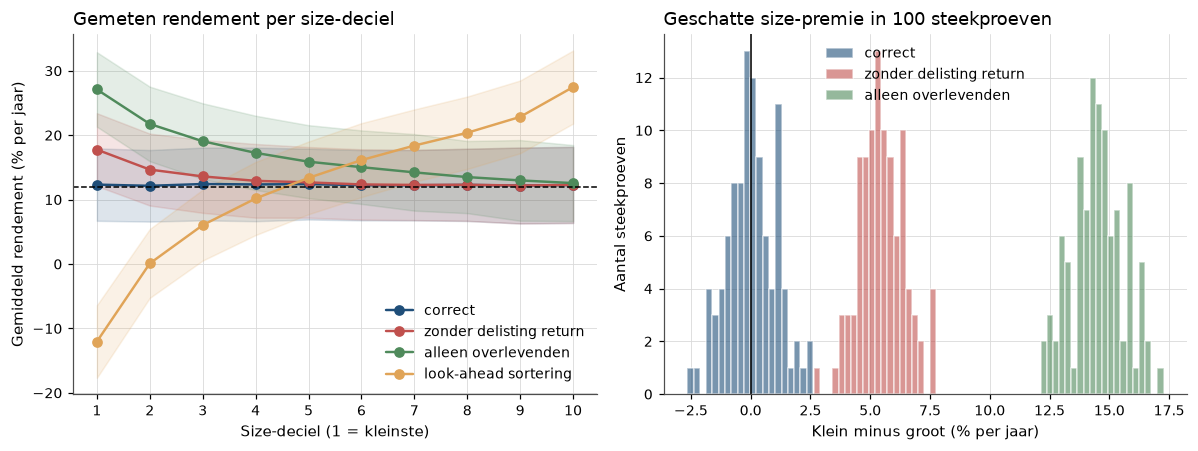

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
deciles_axis = np.arange(1, 11)
for (key, label), color in zip(labels.items(), hap.plotting.COLORS):
    mean = annual[key].mean(axis=0) * 100
    spread = annual[key].std(axis=0, ddof=1) * 100
    axes[0].plot(deciles_axis, mean, marker="o", color=color, label=label)
    axes[0].fill_between(deciles_axis, mean - 2 * spread, mean + 2 * spread, color=color, alpha=0.15)
axes[0].axhline(12, color="black", lw=1, ls="--")
axes[0].set_title("Gemeten rendement per size-deciel")
axes[0].set_xlabel("Size-deciel (1 = kleinste)")
axes[0].set_ylabel("Gemiddeld rendement (% per jaar)")
axes[0].set_xticks(deciles_axis)
axes[0].legend()

for (key, label), color in zip(list(labels.items())[:3], hap.plotting.COLORS):
    premium = (annual[key][:, 0] - annual[key][:, 9]) * 100
    axes[1].hist(premium, bins=20, color=color, alpha=0.6, label=label, edgecolor="white")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("Geschatte size-premie in 100 steekproeven")
axes[1].set_xlabel("Klein minus groot (% per jaar)")
axes[1].set_ylabel("Aantal steekproeven")
axes[1].legend()
fig.tight_layout()
plt.show()

:::{figure} #cel-crsp-tape-sim
:label: fig-crsp-tape-sim
:width: 100%

Een universum zonder size-premie, vier keer gemeten. Links: correct gemeten is het
rendement in elk deciel 12% (stippellijn). Zonder delisting returns en met alleen
overlevenden stijgt het naar het kleine eind, met look-ahead daalt het. De banden zijn twee
standaarddeviaties over de steekproeven. Rechts: de drie verdelingen van de geschatte
premie overlappen niet. Een $t$-toets op de verkeerde database verwerpt "geen
size-premie" in elke steekproef.
:::

De ruis is hier kleiner dan in echte data, omdat het model geen gemeenschappelijke
size-factor heeft. In de French-data hieronder is de standaardfout van de size-premie
twee tot zes procentpunt. Een fout van vijf procentpunt valt daar dus niet op, en meer
jaren data halen haar niet weg.

## Replicatie op echte data

### Wat weging met een eeuw doet

```{admonition} Replicatie
:class: seealso

**Bron.** Fisher & Lorie, *Rates of Return on Investments in Common Stocks*, Journal of
Business 1964 {cite}`FisherLorie1964`, en het jaaroverzicht 1926–65 uit 1968
{cite}`FisherLorie1968`.

**Wat.** Wat de weging doet met het rendement op "alle" aandelen sinds 1926 (de 9,0% zelf
staat in [](#00-01-rendementen)). Het weegverschil in het kleinste deciel is een bovengrens
voor de fout door ontbrekende delisting returns, want alleen equal-weighted geeft dat deciel
gewicht.

**Data hier.** Kenneth French Data Library: tien size-decielen, equal- en
value-weighted, met het aantal bedrijven en de gemiddelde marktwaarde per deciel,
1926–2026.

**Verschil met het origineel.** Fisher en Lorie namen alleen NYSE-aandelen en
herbalanceerden niet. French neemt ook AMEX en Nasdaq en herbalanceert equal-weighted
elke maand, en het gemiddelde over alle bedrijven reconstrueren we uit de decielen.

**Verwachte afwijking.** De uit decielen gereconstrueerde value-weighted markt ligt
binnen 0,1 procentpunt per jaar van de marktreeks. Equal-weighted ligt hoger, en het
weegverschil binnen de decielen zit vrijwel geheel in het kleinste deciel.
```

We laden de decielen en wegen ze met het aantal bedrijven (equal-weighted) of de
totale marktwaarde (value-weighted) van de vorige maand.

In [12]:
deciles = ["Lo 10", "2-Dec", "3-Dec", "4-Dec", "5-Dec", "6-Dec", "7-Dec", "8-Dec", "9-Dec", "Hi 10"]
size_vw = hap_data.french("Portfolios_Formed_on_ME", "monthly")[deciles]
size_ew = hap_data.french("Portfolios_Formed_on_ME", "monthly", table="Equal-Weight")[deciles]
n_firms = hap_data.french("Portfolios_Formed_on_ME", "monthly", table=4)[deciles]
avg_size = hap_data.french("Portfolios_Formed_on_ME", "monthly", table=5)[deciles]
market = hap_data.market_monthly()["Mkt"]

lagged_n = n_firms.shift(1)
lagged_cap = (n_firms * avg_size).shift(1)
ew_all = ((lagged_n * size_ew).sum(axis=1) / lagged_n.sum(axis=1)).dropna()
vw_rebuilt = ((lagged_cap * size_vw).sum(axis=1) / lagged_cap.sum(axis=1)).dropna()

weighting = pd.concat(
    {"VW markt (Mkt)": market, "VW uit decielen": vw_rebuilt, "EW alle bedrijven": ew_all},
    axis=1,
).dropna()

Per reeks berekenen we het rekenkundige en meetkundige gemiddelde, de standaardfout en
de eindwaarde van één dollar.

In [13]:
def describe(r):
    """Annualised arithmetic and geometric mean, volatility, SE and terminal wealth."""
    years = len(r) / 12
    vol = r.std(ddof=1) * np.sqrt(12)
    return pd.Series({"rekenkundig": 12 * r.mean(), "meetkundig": (1 + r).prod() ** (1 / years) - 1,
                      "volatiliteit": vol, "SE gemiddelde": vol / np.sqrt(years),
                      "eindwaarde van 1 dollar": (1 + r).prod()})


weighting.apply(describe).T.round(4)

,rekenkundig,meetkundig,volatiliteit,SE gemiddelde,eindwaarde van 1 dollar
VW markt (Mkt),0.1155,0.1033,0.1834,0.0183,18594.3252
VW uit decielen,0.1163,0.1043,0.1829,0.0183,20281.5365
EW alle bedrijven,0.1466,0.1230,0.2505,0.0250,109503.2389


De reconstructie klopt: 11,63% per jaar uit decielen tegen 11,55% voor de marktreeks.
Equal-weighted ligt rekenkundig 3,1 procentpunt hoger en één dollar groeit tot zes keer
zoveel. Meetkundig is het verschil kleiner, 12,30% tegen 10,33%: de volatielere
equal-weighted reeks verliest meer aan variantie, ondanks de herbalanceringswinst. Er is geen enkel aandeel anders gemeten. De volgende cel zoekt waar het verschil
zit, deciel voor deciel.

In [14]:
gap = weighting["EW alle bedrijven"] - weighting["VW markt (Mkt)"]
decile_gap = size_ew - size_vw
gap_table = pd.DataFrame(
    {"EW - VW (per jaar)": 12 * decile_gap.mean(),
     "SE": 12 * decile_gap.std(ddof=1) / np.sqrt(len(decile_gap))}
)
gap_table.loc["markt: EW alle - VW"] = [12 * gap.mean(), 12 * gap.std(ddof=1) / np.sqrt(len(gap))]
gap_table["t-waarde"] = gap_table.iloc[:, 0] / gap_table["SE"]
gap_table.round(4)

,EW - VW (per jaar),SE,t-waarde
Lo 10,0.0377,0.0072,5.2185
2-Dec,0.0098,0.0046,2.1474
3-Dec,0.0040,0.0034,1.1756
4-Dec,0.0007,0.0035,0.2034
5-Dec,0.0001,0.0032,0.0195
6-Dec,-0.0000,0.0028,-0.0075
7-Dec,-0.0000,0.0030,-0.0127
8-Dec,-0.0017,0.0027,-0.6370
9-Dec,0.0005,0.0025,0.2080
Hi 10,-0.0016,0.0036,-0.4340


**Geslaagd.** Alle drie de verwachtingen uit het replicatieblok komen uit. In het
kleinste deciel is equal-weighted 3,77 procentpunt per jaar beter ($t = 5{,}2$). Vanaf het
derde deciel is het verschil niet van nul te onderscheiden.

Het marktverschil van 3,1 procentpunt heeft twee bronnen. Equal-weighted geeft het
kleinste deciel veel gewicht, omdat daar de meeste bedrijven zitten. Value-weighted geeft
het weinig. Binnen dat deciel doet equal-weighted het bovendien nog eens beter.

Volgens [](#eq-crsp-tape-ewvw) is dat verschil zelf een size-premie binnen het deciel, en de bid-ask
bias en ontbrekende delisting returns kunnen eraan bijdragen. Welk deel waarvan komt, kunnen
deze data niet scheiden. Zijn de andere bronnen niet negatief, dan is 3,77 procentpunt wel
een bovengrens voor wat de weging via ontbrekende delisting returns in dit deciel kan doen.

Het equal-weighted
marktrendement is dus vooral een uitspraak over het kleinste deciel, waar de fouten uit
de theorie het grootst zijn. De figuur toont de eeuw. Let op de afstand tussen de twee
lijnen van het kleinste deciel.

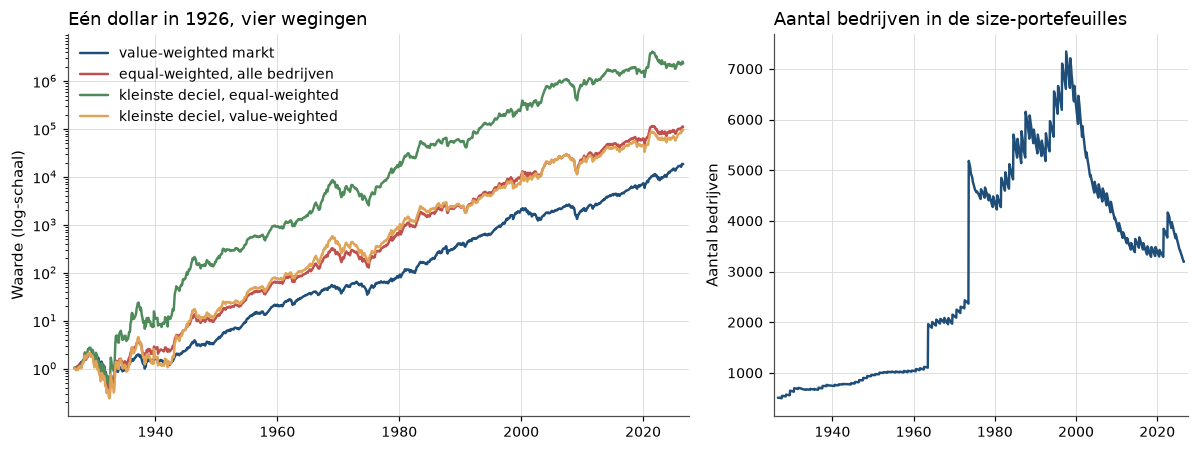

In [15]:
wealth = pd.DataFrame({
    "value-weighted markt": (1 + weighting["VW markt (Mkt)"]).cumprod(),
    "equal-weighted, alle bedrijven": (1 + weighting["EW alle bedrijven"]).cumprod(),
    "kleinste deciel, equal-weighted": (1 + size_ew["Lo 10"].loc[weighting.index]).cumprod(),
    "kleinste deciel, value-weighted": (1 + size_vw["Lo 10"].loc[weighting.index]).cumprod(),
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [3, 2]})
for column, color in zip(wealth.columns, hap.plotting.COLORS):
    axes[0].plot(wealth.index, wealth[column], color=color, label=column)
axes[0].set_yscale("log")
axes[0].set_title("Eén dollar in 1926, vier wegingen")
axes[0].set_xlabel("Jaar")
axes[0].set_ylabel("Waarde (log-schaal)")
axes[0].legend()
hap.plotting.timeline_axis(axes[0])

axes[1].plot(n_firms.index, n_firms.sum(axis=1), color=hap.plotting.COLORS[0])
axes[1].set_title("Aantal bedrijven in de size-portefeuilles")
axes[1].set_xlabel("Jaar")
axes[1].set_ylabel("Aantal bedrijven")
hap.plotting.timeline_axis(axes[1])
fig.tight_layout()
plt.show()

:::{figure} #cel-crsp-tape-weging
:label: fig-crsp-tape-weging
:width: 100%

Links: dezelfde eeuw, vier keer gewogen. Het kleinste deciel equal-weighted eindigt ruim
een orde van grootte boven hetzelfde deciel value-weighted. Het zijn dezelfde aandelen.
Alleen de weging binnen het deciel en het maandelijks herbalanceren verschillen. Rechts:
het universum zelf is geen constante. Het groeide tot eind jaren negentig en kromp
daarna. Elke daling is een verzameling schrappingen, en elke schrapping is een rendement
dat wel of niet in de database staat.
:::

### Shumway: de delisting return en de size-premie

```{admonition} Replicatie
:class: seealso

**Bron.** Shumway, *The Delisting Bias in CRSP Data*, Journal of Finance 1997
{cite}`Shumway1997`; Shumway & Warther, *The Delisting Bias in CRSP's Nasdaq Data and
Its Implications for the Size Effect*, Journal of Finance 1999 {cite}`ShumwayWarther1999`.

**Wat.** De correctie voor ontbrekende delisting returns in de kleinste portefeuille:
Shumway, tabel VII (1962–1992), en Shumway en Warther, tabel IV (Nasdaq, 1972–1995).
Daarnaast de size-premie per deelperiode.

**Data hier.** Er is geen gratis bedrijfsdata met delisting returns. We toetsen de
gepubliceerde correcties daarom aan [](#eq-crsp-tape-delistingbias), en meten de
size-premie in de French-decielen.

**Verschil met het origineel.** De French-portefeuilles gebruiken de huidige
CRSP-bestanden, niet die van 1997. Hoe die met nog ontbrekende delisting returns omgaan,
hebben we niet kunnen verifiëren.

**Verwachte afwijking.** De formule reproduceert beide correcties tot op ongeveer 0,2
procentpunt. De equal-weighted premie is groter dan de value-weighted zolang er een
premie is. Na 1981, toen {cite:t}`Banz1981` publiceerde dat kleine aandelen meer
opbrachten dan het CAPM voorspelde, is ze in beide wegingen niet van nul te onderscheiden.
```

De cel zet de gepubliceerde correcties naast de stelling $h(\mu_a - r^{\text{s}})$. De Nasdaq-rij is
een onafhankelijke toets. De tweede rij haalt $h$ uit dezelfde tabel en toetst dus alleen of
de fout lineair is in $r^{\text{s}}$.

Voor Nasdaq
rapporteren Shumway en Warther $h$ zelf, 2,95% per maand, bij een gemiddeld rendement
$\mu_a$ van 3,79% per maand. Shumways tabel VII geeft jaarrendementen. Zetten we elk
ontbrekend rendement op $-100\%$, dan daalt het kleinste deciel met 5,21 procentpunt per
jaar. Volgens de stelling is dat $12\,h\,(\mu_a + 1)$, met $\mu_a = 21{,}28/12 = 1{,}77\%$
per maand. Daaruit volgt $12\,h = 5{,}21/1{,}0177 = 5{,}12\%$ per jaar, en die $h$ gaat met
$r^{\text{s}} = -30\%$ opnieuw de stelling in.

In [16]:
# Shumway & Warther (1999), table IV, smallest Nasdaq portfolio, % per month:
# 3.79 with CRSP data, 1.97 with missing delisting returns set to -55%; 2.95% delisted per month.
# Shumway (1997), table VII, smallest decile, % per year: 21.28 with CRSP data,
# 19.83 with over-the-counter delisting returns (mean -30%), 16.07 with -100%.
mu_nasdaq = 0.0379                    # monthly mean return, smallest Nasdaq portfolio
h_nasdaq = 0.0295                     # share delisted per month
mu_small = 0.2128 / 12                # monthly mean return, smallest decile (table VII)
h_small_year = (0.2128 - 0.1607) / (1 + mu_small)   # 12 h, from h (mu_a - r_s) with r_s = -100%

published = pd.DataFrame(
    {"origineel": [3.79 - 1.97, 21.28 - 19.83],
     "hier: h (mu_a - r_s)": [100 * h_nasdaq * (mu_nasdaq + 0.55), 100 * h_small_year * (mu_small + 0.30)]},
    index=["Nasdaq, kleinste portefeuille, r_s = -55% (pp per maand)",
           "kleinste deciel, r_s = -30% (pp per jaar)"],
)
published["verschil"] = published["hier: h (mu_a - r_s)"] - published["origineel"]
published.round(3)

,origineel,hier: h (mu_a - r_s),verschil
"Nasdaq, kleinste portefeuille, r_s = -55% (pp per maand)",1.82,1.734,-0.086
"kleinste deciel, r_s = -30% (pp per jaar)",1.45,1.627,0.177


**Geslaagd.** Beide correcties liggen binnen de aangekondigde 0,2 procentpunt van de
stelling: 1,73 tegen 1,82 per maand op Nasdaq, 1,63 tegen 1,45 per jaar bij Shumway. De
hele fout door ontbrekende delisting returns zit in twee getallen: de schrappingskans en het ontbrekende verlies.
Nu de size-premie per deelperiode, met 1981 als grens.

In [17]:
subperiods = {"1926-07 / 1962-12": ("1926-07", "1962-12"),
              "1963-01 / 1981-12": ("1963-01", "1981-12"),
              "1982-01 / 2026-07": ("1982-01", "2026-07"),
              "1926-07 / 2026-07": ("1926-07", "2026-07")}


def premium_stats(panel, start, end):
    """Annualised small-minus-big premium, its standard error and t-statistic."""
    p = (panel["Lo 10"] - panel["Hi 10"]).loc[start:end]
    se = p.std(ddof=1) / np.sqrt(len(p))
    return 12 * p.mean(), 12 * se, p.mean() / se


rows = {}
for name, (start, end) in subperiods.items():
    ew_mean, ew_se, ew_t = premium_stats(size_ew, start, end)
    vw_mean, vw_se, vw_t = premium_stats(size_vw, start, end)
    weighting_gap = ((size_ew["Lo 10"] - size_ew["Hi 10"]) - (size_vw["Lo 10"] - size_vw["Hi 10"])).loc[start:end]
    rows[name] = {"EW premie": ew_mean, "EW SE": ew_se, "EW t": ew_t,
                  "VW premie": vw_mean, "VW SE": vw_se, "VW t": vw_t,
                  "EW - VW": 12 * weighting_gap.mean(),
                  "SE EW - VW": 12 * weighting_gap.std(ddof=1) / np.sqrt(len(weighting_gap))}
size_premium = pd.DataFrame(rows).T
size_premium.round(4)

,EW premie,EW SE,EW t,VW premie,VW SE,VW t,EW - VW,SE EW - VW
1926-07 / 1962-12,0.1861,0.0640,2.9077,0.1034,0.0585,1.7661,0.0827,0.0138
1963-01 / 1981-12,0.1261,0.0430,2.9309,0.0983,0.0410,2.4000,0.0278,0.0110
1982-01 / 2026-07,-0.0005,0.0256,-0.0213,-0.0092,0.0236,-0.3884,0.0086,0.0116
1926-07 / 2026-07,0.0916,0.0273,3.3514,0.0523,0.0251,2.0865,0.0393,0.0076


**Geslaagd.** Vóór 1982 is de equal-weighted premie groter dan de value-weighted, 18,6
tegen 10,3 procentpunt per jaar tot 1962. Na 1981 is de premie in beide wegingen weg,
met standaardfouten van ruim twee procentpunt. Over de volle eeuw scheelt de weging vier
procentpunt, met een standaardfout van het verschil van 0,8 procentpunt.

Hoe kwetsbaar is die premie? De laatste cel rekent terug welke schrappingskans zonder
geregistreerd laatste rendement de equal-weighted premie sinds 1963 volledig zou
verklaren.

In [18]:
monthly_premium = (size_ew["Lo 10"] - size_ew["Hi 10"]).loc["1963-01":"2026-07"].mean()
break_even = pd.DataFrame(
    {"schrappingskans per maand": {f"r_s = {d:.0%}": monthly_premium / -d for d in (-0.30, -0.55, -1.00)},
     "schrappingskans per jaar": {f"r_s = {d:.0%}": 12 * monthly_premium / -d for d in (-0.30, -0.55, -1.00)}}
)
break_even.round(4)

,schrappingskans per maand,schrappingskans per jaar
r_s = -30%,0.0104,0.1244
r_s = -55%,0.0057,0.0678
r_s = -100%,0.0031,0.0373


De rij $r^{\text{s}} = -100\%$ is de premie zelf, 0,31% per maand. Ze verdwijnt als 0,57% van het kleinste deciel per maand
verdwijnt met een ontbrekend rendement van $-55\%$. Shumway en Warther vonden in de
kleinste Nasdaq-portefeuille 2,95% per maand. Die kans is niet exotisch.

French sorteert
op NYSE-breekpunten: de decielgrenzen komen alleen uit NYSE-aandelen, zodat de vele
kleine AMEX- en Nasdaq-aandelen in het kleinste deciel belanden. De cel toont welk deel
van de bedrijven in dat deciel valt.

In [19]:
share_small = n_firms["Lo 10"] / n_firms.sum(axis=1)
share_small.loc[["1956-07-31", "1976-07-31", "2026-07-31"]].rename("aandeel in kleinste deciel").round(3)

date
1956-07-31    0.100
1976-07-31    0.536
2026-07-31    0.386
Name: aandeel in kleinste deciel, dtype: float64

In 1956 viel 10% van de bedrijven in het kleinste deciel, in 1976 ruim de helft en nu nog
bijna 40%. Of de huidige data die rendementen bevatten,
is zonder CRSP niet vast te stellen. Het teken en de omvang van de size-premie hangen dus
af van een veld dat de gebruiker zelden opent.

## Wat er brak, en wat daarna kwam

**Wat de tape verklaart.** Vóór 1964 was er over het rendement op aandelen een mening,
daarna een getal met een definitie. Binnen tien jaar draaiden de eerste event study en
de toetsen van het CAPM op dezelfde band. De keuzes van
Fisher en Lorie zijn nog altijd de standaard: totaalrendementen met herbelegde
dividenden, vanaf 1926, alle genoteerde aandelen. Dat ze de verdwenen bedrijven
meenamen, bleek achteraf de belangrijkste.

**Waar het breekt.** In de velden die leeg bleven en in de keuzes van de gebruiker. De
weging alleen verschuift het marktrendement van een eeuw met 3,1 procentpunt per jaar,
bijna geheel via het kleinste deciel. Shumway en Warther {cite}`ShumwayWarther1999` lieten zien dat het
size-effect op Nasdaq verdwijnt zodra de ontbrekende delisting returns zijn ingevuld: de
$F$-toets op gelijke gemiddelden zakt van 3,52 naar 0,58.

De bouw van de database is voor
de cross-sectie een grotere bron van onzekerheid dan
[de standaardfout van 2%](#00-01-rendementen), de ruis die een eeuw data in een
gemiddelde laat. Meer data halen die fout niet onder de ruis:
de fout door ontbrekende delisting returns blijft staan, en die van overlevenden
krimpt hoogstens even snel als de ruis.

**Risico of vergissing?** Is de size-premie een beloning of een meetfout? De
Chicago-lezing ziet prijzen als juist. Kleine aandelen moeten dan zolang ze bestaan meer
opbrengen, om het verlies bij faillissement goed te maken. Onze simulatie is zo gebouwd,
en correct gemeten is de premie daar nul. Wat in schone data overblijft, zou een
beloning voor risico zijn. De Yale-lezing laat toe dat prijzen ernaast zitten: een
premie die verdwijnt na correctie en na publicatie, was nooit een risicopremie.
{cite:t}`ShumwayWarther1999` vinden hun resultaten slecht te rijmen met
risicoverklaringen. Scheiden kan alleen met een onafhankelijke maat voor
faillissementsrisico plus volledige delisting returns, en die data heeft deze reeks
niet. De simulatie toont hoe groot een premie wordt die de
database zelf maakt.

**Wat er daarna kwam.** De tape leverde de rendementen, maar geen argument voor wat die
rendementen zouden moeten doen. Dat argument gaf Fama met de hypothese van efficiënte
markten: zie [](#02-06-efficiente-markten).

## Oefeningen

:::{exercise}
:label: ex-crsp-tape-1

**Instap: een faillissement zonder restwaarde.** Neem het toy-voorbeeld, maar laat
aandeel C na schrapping niets meer waard zijn ($v = 0$).

1. Bereken de delisting return van C en het correcte marktrendement in periode 3.
2. Hoe groot is nu de fout van de database zonder delisting return in periode 3? Klopt
   dat met $h(\mu_a - r^{\text{s}})$?
:::

:::{solution} ex-crsp-tape-1
:class: dropdown

**(1)** $r^{\text{s}} = 0/6 - 1 = -100\%$. Het correcte marktrendement is $-100/5 = -20\%$.

**(2)** De database zonder delisting return meet $0\%$, een fout van 20 procentpunt. De
formule geeft $0{,}2 \times (0 - (-1)) = 0{,}20$. De cel rekent het na met de functie uit
het toy-voorbeeld.

In [20]:
worthless = total_returns(prices, {"C": (3, 0.0)})
pd.Series({"correct, periode 3": worthless.loc[3].mean(),
           "zonder delisting return, periode 3": worthless.loc[3].drop("C").mean(),
           "formule h (mu_a - r_s)": 0.2 * (0.0 - (-1.0))}).round(4)

correct, periode 3                   -0.2
zonder delisting return, periode 3    0.0
formule h (mu_a - r_s)                0.2
dtype: float64

Wat dit leert: de fout groeit lineair met het ontbrekende verlies. Een database die
faillissementen zonder restwaarde mist, overschat het gemiddelde met de volle
schrappingskans.
:::

:::{exercise}
:label: ex-crsp-tape-2

**Afleiding: survivorship bij drift en bij maandelijkse waarneming.** Neem het model van
[](#thm-crsp-tape-survivorship) met $z_0 = 1$, $\sigma = 50\%$ per jaar en $T = 20$ jaar.

1. Laat zien dat [](#eq-crsp-tape-survivorship) niet geldt als $Z_t$ een drift
   $\nu \neq 0$ heeft. Waar gaat het bewijs mis, en welk proces is dan wel een
   martingaal?
2. Simuleer 20 000 paden met maandelijkse stappen en schrap zodra $Z_t \le 0$ op een
   maandeinde. Vergelijk overleefkans en fout met de formules, en verklaar het teken
   van het verschil.
:::

:::{solution} ex-crsp-tape-2
:class: dropdown

**(1)** Het bewijs gebruikt dat $Z_t$ een martingaal is, zodat $\E[Z_{T\wedge\theta}] = z_0$.
Met drift is $\E[Z_{T\wedge\theta}] = z_0 + \nu\,\E[T\wedge\theta]$, en die verwachte stoptijd
hangt zelf van de drempel af. De martingaal is dan $Z_t - \nu t$. De eenvoudige formule
geldt alleen zonder drift. Bij positieve drift raken minder paden de drempel: de fout
blijft positief, maar wordt kleiner.

**(2)**

In [21]:
n_paths, steps_per_year, horizon, x0, sigma = 20_000, 12, 20, 1.0, 0.50
increments = rng.normal(0.0, sigma / np.sqrt(steps_per_year), size=(n_paths, steps_per_year * horizon))
paths = x0 + increments.cumsum(axis=1)
alive = (paths > 0).all(axis=1)

p_formula, bias_formula = survivor_bias(x0, sigma, horizon)
pd.DataFrame(
    {"simulatie (maandelijks)": [alive.mean(), (paths[alive, -1].mean() - x0) / horizon],
     "formule (continu)": [p_formula, bias_formula]},
    index=["overleefkans", "gem. logrendement overlevenden per jaar"],
).round(4)

,simulatie (maandelijks),formule (continu)
overleefkans,0.3676,0.3453
gem. logrendement overlevenden per jaar,0.0928,0.0948


De gesimuleerde overleefkans (0,368) ligt boven de formule (0,345), en de fout (9,3%)
eronder (9,5%). Dat teken is te verwachten. Een pad dat tussen twee maandeinden kort onder
de drempel duikt, wordt bij maandelijkse waarneming niet geschrapt, dus de selectie is
iets milder.

Wat dit leert: survivorship bias is geen eigenschap van één model maar van selectie op
een drempel. Hoe strenger de selectie, hoe groter de fout.
:::

:::{exercise}
:label: ex-crsp-tape-3

**Uitbreiding van de replicatie: waar en wanneer zit het weegverschil?** Gebruik
`size_ew`, `size_vw` en `ew_all` uit de replicatie.

1. Bereken voor 1926–1962, 1963–1981 en 1982–2026 het verschil tussen equal- en
   value-weighted in het kleinste en het grootste deciel, met standaardfouten.
2. Bereken voor dezelfde perioden het verschil in meetkundig gemiddelde tussen `ew_all`
   en de value-weighted markt. Is het groter of kleiner dan het rekenkundige verschil?
3. Is het weegverschil in het kleinste deciel na 1981 verdwenen, zoals de size-premie?
:::

:::{solution} ex-crsp-tape-3
:class: dropdown

In [22]:
rows = {}
vw_market = weighting["VW markt (Mkt)"]
for name, (start, end) in list(subperiods.items())[:3]:
    small = (size_ew["Lo 10"] - size_vw["Lo 10"]).loc[start:end]
    large = (size_ew["Hi 10"] - size_vw["Hi 10"]).loc[start:end]
    ew_part, vw_part = ew_all.loc[start:end], vw_market.loc[start:end]
    years = len(ew_part) / 12
    rows[name] = {
        "Lo 10: EW-VW": 12 * small.mean(), "Lo 10: SE": 12 * small.std(ddof=1) / np.sqrt(len(small)),
        "Hi 10: EW-VW": 12 * large.mean(), "Hi 10: SE": 12 * large.std(ddof=1) / np.sqrt(len(large)),
        "markt rekenk. EW-VW": 12 * (ew_part.mean() - vw_part.mean()),
        "markt meetk. EW-VW": (1 + ew_part).prod() ** (1 / years) - (1 + vw_part).prod() ** (1 / years),
    }
pd.DataFrame(rows).T.round(4)

,Lo 10: EW-VW,Lo 10: SE,Hi 10: EW-VW,Hi 10: SE,markt rekenk. EW-VW,markt meetk. EW-VW
1926-07 / 1962-12,0.0798,0.0143,-0.0029,0.0053,0.0506,0.0326
1963-01 / 1981-12,0.0305,0.0077,0.0026,0.0075,0.0697,0.0650
1982-01 / 2026-07,0.0064,0.0106,-0.0022,0.0060,-0.0014,-0.0102


**(1) en (3)** Binnen het kleinste deciel krimpt het verschil van 8,0 procentpunt per jaar
vóór 1963 via 3,1 tot 0,6 na 1981, met een standaardfout van 1,1. Het is na 1981 dus niet
meer van nul te onderscheiden. In het grootste deciel ligt het in alle perioden binnen drie
tienden van een procentpunt. Krimpende spreads en vollediger delisting returns passen bij
dit patroon, maar een verdwijnende premie binnen het deciel ook.

**(2)** Het meetkundige verschil is in elke periode kleiner dan het rekenkundige. De
volatielere equal-weighted markt verliest meer aan variantie. De winst uit
[](#eq-crsp-tape-bonus) geldt ten opzichte van de eigen onderdelen, niet ten opzichte van
een andere portefeuille.

Wat dit leert: "het" marktrendement bestaat niet. Elke uitspraak erover is een uitspraak
over een periode en een weging.
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->